# LangGraph 101

[LLMs](https://python.langchain.com/docs/concepts/chat_models/) 讓我們得以把智慧嵌入一類全新的應用程式中。[LangGraph](https://langchain-ai.github.io/langgraph/) 是一套協助你用 LLM 建構應用程式的框架。在這裡，我們會綜覽 LangGraph 的基礎、說明它的好處、示範如何用它來建構 workflow / agent，並展示它如何與 [LangChain](https://www.langchain.com/) / [LangSmith](https://docs.smith.langchain.com/) 搭配運作。

![ecosystem](./img/ecosystem.png)

## Chat models

[Chat models](https://python.langchain.com/docs/concepts/chat_models/) 是 LLM 應用程式的基礎。它們通常透過一個聊天介面來存取：以一串 [messages](https://python.langchain.com/docs/concepts/messages/) 作為輸入，並回傳一則 [message](https://python.langchain.com/docs/concepts/messages/) 作為輸出。LangChain 為 chat models 提供了[一套標準化的介面](https://python.langchain.com/api_reference/langchain/chat_models/langchain.chat_models.base.init_chat_model.html)，讓你能輕鬆[存取許多不同的供應商](https://python.langchain.com/docs/integrations/chat/)。

In [1]:
from dotenv import load_dotenv
load_dotenv("../.env", override=True)

True

In [3]:
from langchain.chat_models import init_chat_model

In [4]:
# "openai:gpt-4.1" 這個冒號語法是 LangChain 的統一入口：冒號左邊是供應商，右邊是型號。
# 換成 "anthropic:claude-sonnet-4-5" 就換供應商，底下的 bind_tools、invoke、
# 整張 graph 一行都不用改——這就是 markdown 裡說的「標準化介面」的實際意思。
#
# temperature=0 = 每次都挑機率最高的字，輸出盡量穩定。
# 教學和後面的 evaluation 章節都要能重現結果，所以固定成 0。
llm = init_chat_model("openai:gpt-4.1", temperature=0)

## 執行 model

`init_chat_model` 介面提供了[標準化](https://python.langchain.com/docs/concepts/runnables/)的方法來使用 chat models，其中包括：
- `invoke()`：把單一輸入轉換成一個輸出。
- `stream()`：在輸出產生的同時就以[串流](https://python.langchain.com/docs/concepts/streaming/#stream-and-astream)方式回傳。

In [7]:
result = llm.invoke("Agent是什麼？")

In [8]:
print(result)

content='“Agent”這個詞在不同的領域有不同的意思，以下是幾個常見的解釋：\n\n1. **一般意義**  \n   Agent 指的是“代理人”或“代理者”，即代表他人行事的人。例如：房地產經紀人（real estate agent）、保險代理人（insurance agent）。\n\n2. **計算機科學/人工智慧**  \n   在人工智慧（AI）和計算機科學中，Agent 通常指的是一個能夠自主感知環境、做出決策並執行行動的軟體或系統。例如：  \n   - 聊天機器人（Chatbot）  \n   - 自動駕駛汽車中的決策系統  \n   - 遊戲中的 NPC（非玩家角色）  \n   - OpenAI 的 AI Agent，可以根據指令自動完成任務\n\n3. **化學/生物學**  \n   在化學或生物學中，Agent 可以指“劑”或“作用物”，例如：  \n   - 抗生素（antibiotic agent）  \n   - 清潔劑（cleaning agent）  \n   - 催化劑（catalytic agent）\n\n4. **商業/法律**  \n   在商業或法律領域，Agent 是指受雇於某人或某公司，並代表其行事的人或公司。\n\n---\n\n**總結**：  \nAgent 的核心概念是“代表、執行、作用”，具體含義要根據上下文來判斷。如果你有特定的領域或例子，歡迎補充，我可以給你更詳細的解釋！' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 378, 'prompt_tokens': 12, 'total_tokens': 390, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': '

In [9]:
type(result)

langchain_core.messages.ai.AIMessage

In [10]:
from rich.markdown import Markdown
Markdown(result.content)

“Agent”這個詞在不同的領域有不同的意思，以下是幾個常見的解釋：                                                      

 1 一般意義                                                                                                        
   Agent 指的是“代理人”或“代理者”，即代表他人行事的人。例如：房地產經紀人（real estate                             
   agent）、保險代理人（insurance agent）。                                                                        
 2 計算機科學/人工智慧                                                                                             
   在人工智慧（AI）和計算機科學中，Agent 通常指的是一個能夠自主感知環境、做出決策並執行行動的軟體或系統。例如：    
    • 聊天機器人（Chatbot）                                                                                        
    • 自動駕駛汽車中的決策系統                                                                                     
    • 遊戲中的 NPC（非玩家角色）                                                                                   
    • OpenAI 的 AI Agent，可以根據指令自動完成任務                                                                 
 3 化學/生物學                                                                                                     
   在化學或生物學中，Agent 可以指“劑”或“作用物”，例如：                                                            
    • 抗生素（antibiotic agent）                                                                                   
    • 清潔劑（cleaning agent）                                                                                     
    • 催化劑（catalytic agent）                                                                                    
 4 商業/法律                                                                                                       
   在商業或法律領域，Agent 是指受雇於某人或某公司，並代表其行事的人或公司。                                        

-------------------------------------------------------------------------------------------------------------------

總結：                                                                                                             
Agent                                                                                                              
的核心概念是“代表、執行、作用”，具體含義要根據上下文來判斷。如果你有特定的領域或例子，歡迎補充，我可以給你更詳細的 
解釋！

## Tools

[Tools](https://python.langchain.com/docs/concepts/tools/) 是可以被 chat model 呼叫的工具函式。在 LangChain 中，你可以用 `@tool` decorator 來建立 tool，它會把 Python 函式轉換成可呼叫的 tool，並自動從函式定義推斷出該 tool 的名稱、描述與預期參數。你也可以把 [Model Context Protocol (MCP) servers](https://github.com/langchain-ai/langchain-mcp-adapters) 當作與 LangChain 相容的 tools 來使用。

In [11]:
from langchain.tools import tool

# @tool 這個 decorator 一口氣做了三件事，而且每一件後面都會用到：
#   1. 把普通函式包成 StructuredTool 物件（下一個 cell 的 type() 就是在看這個）
#   2. 讀 type hints（to: str, subject: str...）自動生出參數 schema，
#      LLM 就是照這份 schema 決定要填哪些欄位、填什麼型別
#   3. 把 docstring 抓去當這個 tool 的 description
#
# ⚠️ 踩雷：docstring 不是寫給同事看的註解，它是 LLM 唯一讀得到的「工具說明書」。
#    LLM 看不到函式裡面寫什麼，它要不要用這個 tool、什麼時候用，就只憑這一行字判斷。
#    寫「撰寫並寄出一封 email。」它才知道何時該叫它；寫成「處理資料」或乾脆不寫，
#    LLM 就會選錯工具或亂填參數——而且不會拋例外，只會安靜地做錯事。
#    這是新手最容易忽略的地方：改 docstring 等於改 prompt。
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """撰寫並寄出一封 email。"""
    # 佔位回應 - 真實應用中會實際寄出 email
    return f"郵件寄給 {to} 主題是 '{subject}' 內容是 {content}"

In [14]:
type(write_email)
#已經被包裝成“langchain_core.tools.structured.StructuredTool”, 他是一種可以被chat model呼叫的工具,

langchain_core.tools.structured.StructuredTool

In [15]:
# 這份 schema 沒有一個字是手寫的，全是 @tool 從 type hints 長出來的：
# to: str  →  {'to': {'title': 'To', 'type': 'string'}}
# 所以 tool 的 type hints 不是寫好看的——漏一個 hint，LLM 就少一個欄位可以填。
write_email.args

{'to': {'title': 'To', 'type': 'string'},
 'subject': {'title': 'Subject', 'type': 'string'},
 'content': {'title': 'Content', 'type': 'string'}}

In [16]:
# 印出來就是那行 docstring，原封不動。這是上面那條踩雷的證據：
# 你寫的 docstring 會被一字不漏地塞進 prompt 送給 LLM。
Markdown(write_email.description)

撰寫並寄出一封 email。

## Tool Calling

Tools 可以被 LLM [呼叫](https://python.langchain.com/docs/concepts/tool_calling/)。當一個 tool 被綁定到 model 之後，model 可以選擇呼叫該 tool，方法是回傳一個帶有 tool 參數的 structured output。我們使用 `bind_tools` 方法來為 LLM 加上 tools。

![tool-img](img/tool_call_detail.png)

供應商通常會提供[像 `tool_choice` 這樣的參數](https://python.langchain.com/docs/how_to/tool_choice/)來強制呼叫特定的 tools。`any` 會至少選擇其中一個 tool。

此外，我們也可以[設定 `parallel_tool_calls=False`](https://python.langchain.com/docs/how_to/tool_calling_parallel/)，以確保 model 一次只呼叫一個 tool。

In [17]:
# bind_tools = 把 tool 的 schema 塞進送給 LLM 的 request 裡，等於「給它一份菜單」。
# 注意 llm 本身沒被改動，bind_tools 回傳的是一個新物件。
#
# tool_choice="any" = 強迫 LLM 這回合一定要點菜單上的某一道，不准用純文字回話。
#   對照組：預設的 "auto" 是 LLM 自己決定要不要用 tool；填 "write_email" 則是指定非用這道不可。
#   ⚠️ 踩雷：一旦強制，LLM 就再也沒辦法「用講的說我做完了」——它每一輪都只會再開一張工單。
#      後面 agent.ipynb 之所以要多做一個 Done tool 讓 LLM 呼叫，就是為了在這種強制模式下
#      給它一個台階下（否則迴圈永遠停不了）。這兩個參數在後面會變成關鍵設計。
#
# parallel_tool_calls=False = 一次只准開一張工單。
#   對照組：預設 True 時 LLM 可能一口氣回三個 tool_calls，你的程式就得處理一串而不是一個。
model_with_tools = llm.bind_tools([write_email], tool_choice="any", parallel_tool_calls=False)

# invoke 之後，output 裡不會有「寄出去的信」，只會有「我想這樣寄」的 tool_calls（往下看）
output = model_with_tools.invoke("草擬一份給老闆的回覆信件 (boss@company.ai) 關於明天的會議")

In [18]:
type(output)

langchain_core.messages.ai.AIMessage

In [19]:
output

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 112, 'prompt_tokens': 83, 'total_tokens': 195, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_308557f23b', 'id': 'chatcmpl-Dy8eFpiGUu4hDLmqk85zQXGLZzRnt', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f3082-9d8a-7ed3-8ab5-36a049a40ef8-0', tool_calls=[{'name': 'write_email', 'args': {'to': 'boss@company.ai', 'subject': '關於明天會議的回覆', 'content': '親愛的老闆您好：\n\n感謝您的通知，已收到關於明天會議的相關資訊。我會準時參加，並做好相關準備。如有需要我提前準備的資料或主題，請隨時告知。\n\n謝謝您！\n\n敬祝  順心\n\n[您的名字]'}, 'id': 'call_ZXfCQsOoOretHuCX969psexC', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 83, 'output_tokens': 112,

In [20]:
# 整章最重要的前提：LLM 不會寄信。它從頭到尾只做一件事——「說」它想寄，
# 把收件人／主旨／內容填成一包參數交出來，放在 tool_calls 裡。
# 上一個 cell 的 output 你會看到 content='' 是空字串，因為它把話全講在 tool_calls 裡了。
#
# 所以 bind_tools 只是給菜單、LLM 只是點菜，端菜的必須是你自己的 Python（下一個 cell）。
# 沒人去執行的話，這封信永遠不會寄出，而且不會有任何錯誤——程式跑完，事情沒做。
args = output.tool_calls[0]['args']
args

{'to': 'boss@company.ai',
 'subject': '關於明天會議的回覆',
 'content': '親愛的老闆您好：\n\n感謝您的通知，已收到關於明天會議的相關資訊。我會準時參加，並做好相關準備。如有需要我提前準備的資料或主題，請隨時告知。\n\n謝謝您！\n\n敬祝  順心\n\n[您的名字]'}

In [21]:
# 真正執行 write_email 的是這行 Python，不是 LLM。
#
# 「讀 output.tool_calls → 執行對應的函式 → 把結果收回來」——這兩個 cell 手工做的事，
# 就是 agent 迴圈的全部內容。後面的 run_tool node、create_react_agent，
# 幫你自動化的也就只是這件事。先看懂這個手工版，才知道那些抽象在幫你省什麼。
result = write_email.invoke(args)
Markdown(result)

郵件寄給 boss@company.ai 主題是 '關於明天會議的回覆' 內容是 親愛的老闆您好：                                       

感謝您的通知，已收到關於明天會議的相關資訊。我會準時參加，並做好相關準備。如有需要我提前準備的資料或主題，請隨時告 
知。                                                                                                               

謝謝您！                                                                                                           

敬祝  順心                                                                                                         

[您的名字]

![basic_prompt](img/tool_call.png)

## Workflows
 
用 LLM 建構應用程式有許多種模式。

[我們可以把 LLM 呼叫嵌入預先定義好的 workflow 中](https://langchain-ai.github.io/langgraph/tutorials/workflows/)，讓系統擁有更多自主決策的能力。

舉例來說，我們可以加上一個 router 步驟，用來判斷究竟要不要寫一封 email。

![workflow_example](img/workflow_example.png)

## Agents

我們可以進一步提高自主性，讓 LLM 動態地主導自己對 tool 的使用。

[Agents](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) 通常會被實作成一個 tool calling 的迴圈：每次 tool call 的輸出都會用來決定下一步的動作。

![agent_example](img/agent_example.png)

Agents 很適合用在開放式的問題上，也就是那些難以事先預測*確切*步驟的情境。
 
而當控制流程可以輕易事先定義時，workflow 往往更為合適。

![workflow_v_agent](img/workflow_v_agent.png)

## 什麼是 LangGraph？

[LangGraph](https://langchain-ai.github.io/langgraph/concepts/high_level/) 提供位於底層的支援基礎設施，墊在*任何* workflow 或 agent 之下。

它不會把 prompt 或架構抽象化掉，並帶來以下幾項好處：

- **Control（控制）**：讓你能輕鬆定義以及／或組合 agent 與 workflow。
- **Persistence（持久化）**：提供一種方式來保存 graph 的 state，進而同時支援 memory 與 human-in-the-loop。
- **Testing、Debugging 與 Deployment**：為測試、除錯與部署應用程式提供一條簡單的上手途徑。

### Control

LangGraph 讓你把應用程式定義成一張 graph，其中包含：

1. *State*：在整個應用程式的執行過程中，我們需要追蹤哪些資訊？
2. *Nodes*：在整個應用程式的執行過程中，我們想如何更新這些資訊？
3. *Edges*：我們想如何把這些 nodes 連接在一起？

我們可以用 [`StateGraph` class](https://langchain-ai.github.io/langgraph/concepts/low_level/#graphs) 搭配一個 [`State` object](https://langchain-ai.github.io/langgraph/concepts/low_level/#state) 來初始化一張 LangGraph graph。

`State` 定義了我們想在整個應用程式執行過程中追蹤之資訊的 schema。

它可以是 Python 中任何具備 `getattr()` 的物件，例如 dictionary、dataclass 或 Pydantic object：

- TypeDict 最快，但不支援預設值
- Dataclass 幾乎一樣快，支援 `state.foo` 這樣的點記法，而且有預設值。
- Pydantic 較慢（尤其在搭配自訂 validator 時），但能提供型別驗證。

In [22]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class StateSchema(TypedDict):
    request: str
    email: str

workflow = StateGraph(StateSchema)

每個 node 其實就是一個 Python 函式或一段 TypeScript 程式碼。這讓我們能完全掌控每個 node 內部的邏輯。

它們會接收目前的 state，並回傳一個 dictionary 來更新 state。

預設情況下，[state 的 key 會被覆寫](https://langchain-ai.github.io/langgraph/how-tos/state-reducers/)。

不過，你也可以[定義自訂的更新邏輯](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers)。

![nodes_edges](img/nodes_edges.png)

In [23]:
# 這是 workflow，不是 agent。判準只有一句話：誰決定下一步？
# 這裡「先 invoke LLM → 再取 args → 再執行 write_email → 再回傳 email」的順序是你寫死的，
# LLM 完全沒有決定權，它只是被叫來填信件內容的填空機。你決定流程 = workflow。
# 對照組在下面 call_llm / should_continue / run_tool 那段：那裡下一步由 LLM 的輸出決定。
def write_email_node(state: StateSchema) -> StateSchema:
    # 處理 request 的指令式程式碼
    output = model_with_tools.invoke(state["request"])
    print(output)
    args = output.tool_calls[0]['args']
    print(args)
    email = write_email.invoke(args)
    return {"email": email}

Edges 會把 nodes 連接在一起。

我們透過在 state graph 中加入 edges 與 nodes 來指定控制流程。

In [24]:
workflow = StateGraph(StateSchema)
workflow.add_node("write_email_node", write_email_node)
workflow.add_edge(START, "write_email_node")
workflow.add_edge("write_email_node", END)

app = workflow.compile()

In [25]:
app.invoke({"request": "草擬一份給老闆的回覆信件 (boss@company.ai) 關於明天的會議"})

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 112, 'prompt_tokens': 83, 'total_tokens': 195, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_308557f23b', 'id': 'chatcmpl-Dy8yXsDr1NcKHek9Wk7taOMEfQOYG', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019f3095-cfb9-7681-87db-b25881c2380a-0' tool_calls=[{'name': 'write_email', 'args': {'to': 'boss@company.ai', 'subject': '關於明天會議的回覆', 'content': '親愛的老闆您好：\n\n感謝您的通知，已收到關於明天會議的相關資訊。我會準時出席，並做好相關準備。如有需要我提前準備的資料或主題，請隨時告知。\n\n謝謝您！\n\n敬祝  順心\n\n[您的名字]'}, 'id': 'call_NBZK9N1Qc88SbrgkfmJqdXwB', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 83, 'output_tokens': 112, 'total_tokens':

{'request': '草擬一份給老闆的回覆信件 (boss@company.ai) 關於明天的會議',
 'email': "郵件寄給 boss@company.ai 主題是 '關於明天會議的回覆' 內容是 親愛的老闆您好：\n\n感謝您的通知，已收到關於明天會議的相關資訊。我會準時出席，並做好相關準備。如有需要我提前準備的資料或主題，請隨時告知。\n\n謝謝您！\n\n敬祝  順心\n\n[您的名字]"}

Nodes 之間的路由可以使用一個簡單的函式來[依條件進行](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges)。

這個函式的回傳值會被當作接下來要把 state 送往的 node 名稱（或一串 node 名稱）。

你也可以選擇性地提供一個 dictionary，把 `should_continue` 的輸出對應到下一個 node 的名稱。

In [26]:
from typing import Literal
from langgraph.graph import MessagesState
from email_assistant.utils import show_graph

# MessagesState = LangGraph 內建的 state schema，只有一個 key：messages。
# 它自帶 reducer，所以 node 回傳 {"messages": [x]} 是「append 一則」而不是「整串蓋掉」。
# ⚠️ 踩雷：改用自己寫的 TypedDict 卻忘了加 reducer，對話會每跑一個 node 就被洗掉一次，
#    而且不會報錯——只會看到 LLM 莫名其妙失憶。

def call_llm(state: MessagesState) -> MessagesState:
    """執行 LLM"""

    output = model_with_tools.invoke(state["messages"])
    return {"messages": [output]}

def run_tool(state: MessagesState):
    """執行 tool call"""

    # 這就是上面「手工版」那兩個 cell 搬進 node 裡：讀 tool_calls → 執行 → 把結果包成 tool message。
    # ⚠️ tool_call_id 一定要原封不動帶回去，LLM 靠它把「這個結果」對上「我剛才發的那張工單」。
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        observation = write_email.invoke(tool_call["args"])
        result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
    return {"messages": result}

def should_continue(state: MessagesState) -> Literal["run_tool", "__end__"]:
    """路由到 tool handler，若呼叫了 Done tool 則結束"""
    # ⚠️ 教材錯誤：上面這行 docstring 和下面「檢查它是不是 Done tool call」是從 agent.ipynb
    #    複製過來忘了改的。這個 notebook 根本沒有 Done tool，這裡只判斷「有沒有 tool_calls」。
    #    教課時別照著念。
    #
    # conditional edge 的函式：回傳值就是「接下來要去哪個 node」的名字。
    # 這個函式是 agent 的大腦——它讀的是 LLM 剛吐出來的東西，不是你排好的行程表。
    
    # 取得最後一則 message
    messages = state["messages"]
    last_message = messages[-1]
    
    # 如果最後一則 message 是 tool call，檢查它是不是 Done tool call
    if last_message.tool_calls:
        return "run_tool"
    # 否則就停止（回覆使用者）
    return END

workflow = StateGraph(MessagesState)
workflow.add_node("call_llm", call_llm)
workflow.add_node("run_tool", run_tool)
workflow.add_edge(START, "call_llm")

# 這行就是 workflow 和 agent 的分水嶺：call_llm 跑完要去哪，不是寫死的，
# 而是把 state 交給 should_continue，看 LLM 這次吐了什麼才決定。LLM 決定 = agent。
# 第三個參數那份 dict 是「回傳值 → node 名稱」的對照表（可省略，省略時回傳值直接當 node 名）。
workflow.add_conditional_edges("call_llm", should_continue, {"run_tool": "run_tool", END: END})

# ⚠️ 看清楚：是 run_tool → END，不是 run_tool → call_llm。
#    所以這張圖只跑一輪（LLM 講一次、tool 執行一次）就結束，並不是真正的 ReAct 迴圈：
#    tool 的執行結果沒有送回去給 LLM 看，LLM 也就沒機會根據結果決定下一步。
#    這是教材刻意的簡化——這一段的重點是示範 conditional edge，不是示範迴圈。
#    （況且上面 bind_tools 綁了 tool_choice="any"，真接回 call_llm 會永遠停不下來：
#      LLM 每輪都被迫開工單，should_continue 就永遠回 "run_tool"。）
#
#    真迴圈長什麼樣？看下一段的 create_react_agent，或 agent.ipynb 裡的
#    add_edge("tool_handler", "llm_call")——把 tool 結果丟回 LLM，
#    再由 should_continue 決定要不要收工。那才是 ReAct。
workflow.add_edge("run_tool", END)

# 執行 workflow
app = workflow.compile()

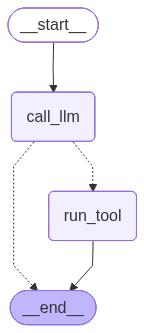

In [27]:
show_graph(app)

In [28]:
result = app.invoke({"messages": [{"role": "user", "content": "草擬一份給老闆的回覆信件 (boss@company.ai) 關於明天的會議"}]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

草擬一份給老闆的回覆信件 (boss@company.ai) 關於明天的會議
================================== Ai Message ==================================
Tool Calls:
  write_email (call_b13FzfDvBlf2NaO19KXPi8MV)
 Call ID: call_b13FzfDvBlf2NaO19KXPi8MV
  Args:
    to: boss@company.ai
    subject: Re: 關於明天的會議
    content: 您好：

感謝您的通知，已收到關於明天會議的相關資訊。我會準時出席，並做好相關準備。如有需要我提前準備的資料或主題，請隨時告知。

謝謝！

敬祝
順心

[您的名字]
================================= Tool Message =================================

郵件寄給 boss@company.ai 主題是 'Re: 關於明天的會議' 內容是 您好：

感謝您的通知，已收到關於明天會議的相關資訊。我會準時出席，並做好相關準備。如有需要我提前準備的資料或主題，請隨時告知。

謝謝！

敬祝
順心

[您的名字]


有了這些底層元件，你就能建構出非常多種不同的 workflow 與 agent。請參考[這份教學](https://langchain-ai.github.io/langgraph/tutorials/workflows/)！

由於 agent 是如此常見的一種模式，[LangGraph](https://langchain-ai.github.io/langgraph/tutorials/workflows/#pre-built) 提供了[一個預先建好的 agent](https://langchain-ai.github.io/langgraph/agents/overview/?ref=blog.langchain.dev#what-is-an-agent) 抽象。

使用 LangGraph 的[預建方法](https://langchain-ai.github.io/langgraph/tutorials/workflows/#pre-built)，我們只要傳入 LLM、tools 與 prompt 即可。

In [29]:
from langgraph.prebuilt import create_react_agent

# 上面手工搭的那一整段（call_llm + run_tool + should_continue + 三條 edge），
# prebuilt 一行就給你，而且是「tool 結果會接回 LLM」的真迴圈版本。
#
# 那為什麼還要手工搭一次？因為知道手工怎麼做，才看得懂這行到底幫你做了什麼、
# 以及哪裡不夠用時要拆開來改（後面幾章的 email assistant 就是拆開來改的）。
#
# 注意這裡傳的是 llm，不是 model_with_tools：tools 交給 create_react_agent 自己 bind，
# 而它不會強制 tool_choice="any"，所以 LLM 做完事後能用純文字說「我寫好了」收尾——
# 這就是為什麼這個版本不需要 Done tool 也停得下來（對照上面 bind_tools 那條踩雷）。
#
# ⚠️ 執行時會跳一行 deprecation warning：LangGraph V1.0 起這個函式搬到
#    from langchain.agents import create_agent。目前照舊寫法仍可執行，不影響教學。
agent = create_react_agent(
    model=llm,
    tools=[write_email],
    prompt="Respond to the user's request using the tools provided."  
)

# 執行 agent
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!"}]}
)

for m in result["messages"]:
    m.pretty_print()

/var/folders/px/22qqx_qn399gggmw1gsvgk000000gn/T/ipykernel_7788/3038892965.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


================================ Human Message =================================

Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!
================================== Ai Message ==================================
Tool Calls:
  write_email (call_gZJexAmKVTOZMltBulN5Xvrx)
 Call ID: call_gZJexAmKVTOZMltBulN5Xvrx
  Args:
    to: boss@company.ai
    subject: Confirmation: Attendance at Interrupt!
    content: Dear [Boss's Name],

Thank you for the opportunity. I would like to confirm that I am interested in attending Interrupt! Please let me know if there are any next steps or additional information needed from my side.

Best regards,
[Your Name]
================================= Tool Message =================================
Name: write_email

郵件寄給 boss@company.ai 主題是 'Confirmation: Attendance at Interrupt!' 內容是 Dear [Boss's Name],

Thank you for the opportunity. I would like to confirm that I am interested in attending Interrupt! Please let me know 

### Persistence

#### Threads

讓 agent 能在執行長時間任務時暫停下來，往往非常有用。

LangGraph 內建了一層持久化機制，透過 checkpointer 來實現這一點。

當你用 checkpointer 編譯 graph 時，checkpointer 會在每一個步驟保存一份 graph state 的 [checkpoint](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpoints)。

Checkpoints 會被保存到一個 thread 中，在 graph 執行結束後仍可加以存取。

![checkpointer](img/checkpoints.png)

我們用一個 [checkpointer](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpointer-libraries) 來編譯 graph。

In [38]:
from langgraph.checkpoint.memory import InMemorySaver

# ⚠️ 前提揭露（這段的全部重點）：LLM 本身沒有記憶。每次 API 呼叫對它來說都是全新的一張白紙。
#    接下來三個 cell 之所以能「記得」前面聊過什麼，不是 LLM 變聰明了，
#    而是 checkpointer 把整串 messages 存著，每次 invoke 再原封不動地全部重送一次給它。
#    記憶不是 LLM 的能力，是 checkpointer 給的。
#
# checkpointer = 存檔機制：每跑完一個 node，就把當下的 state 存成一個 checkpoint。
# InMemorySaver 存在 RAM，kernel 一重啟就全沒了。正式環境會換成 Postgres/SQLite 版的
# checkpointer，換一行而已，其他程式碼不用動。
agent = create_react_agent(
    model=llm,
    tools=[write_email],
    prompt="Respond to the user's request using the tools provided.",
    checkpointer=InMemorySaver()
)

# thread_id = 這次對話的「存檔名稱」。所有 checkpoint 都掛在同一個 thread_id 底下，
# 串成一條時間線。接下來三個 cell 都傳同一個 config，所以是同一場對話的連續追問。
#
# 為什麼要包在 configurable 裡這麼囉嗦？這是 LangChain Runnable 的通用慣例：
# configurable 放「執行時才決定」的參數，LangGraph 沿用它，所以 thread_id 得多包一層。
#
# ⚠️ 踩雷：換一個 thread_id（例如 "2"）等於開新存檔，前面的對話完全不存在，
#    而且不會有任何錯誤或警告——LLM 只是突然失憶。
#    另一種寫錯法比較幸運：config 整個不傳會直接拋 ValueError
#    （Checkpointer requires one or more of the following 'configurable' keys: thread_id...），
#    因為 compile 時給了 checkpointer，它就非要知道要存到哪個 thread 不可。
config = {"configurable": {"thread_id": "1"}}
result = agent.invoke({"messages": [{"role": "user", "content": "What are some good practices for writing emails?"}]}, config)
                    

/var/folders/px/22qqx_qn399gggmw1gsvgk000000gn/T/ipykernel_7788/1218495830.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [39]:
# 取得最新的 state 快照
config = {"configurable": {"thread_id": "1"}}
state = agent.get_state(config)
for message in state.values['messages']:
    message.pretty_print()

================================ Human Message =================================

What are some good practices for writing emails?
================================== Ai Message ==================================

Here are some good practices for writing effective emails:

1. **Use a Clear Subject Line:** Make your subject concise and informative so the recipient knows what to expect.

2. **Greet Appropriately:** Start with a polite greeting (e.g., “Hello [Name],” or “Dear [Name],”).

3. **Be Concise and to the Point:** State your purpose early and keep your message focused.

4. **Use Proper Formatting:** Break your email into short paragraphs or bullet points for readability.

5. **Be Polite and Professional:** Use courteous language and maintain a professional tone, even if the email is informal.

6. **Proofread Before Sending:** Check for spelling, grammar, and clarity to avoid misunderstandings.

7. **Include a Clear Call to Action:** If you need a response or action, state it clear

In [40]:
# 這次只丟了一句新的話，完全沒有重貼前面的對話，但 config 是同一個 thread_id，
# 所以 checkpointer 會先把存檔撈回來，把新訊息接在後面，再整串送給 LLM。
# 「lesson 3」指的是上一輪 LLM 列的第 3 點——它答得出來，就是記憶生效的證據。
result = agent.invoke({"messages": [{"role": "user", "content": "Good, let's use lesson 3 to craft a response to my boss confirming that I want to attend Interrupt"}]}, config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

What are some good practices for writing emails?
================================== Ai Message ==================================

Here are some good practices for writing effective emails:

1. **Use a Clear Subject Line:** Make your subject concise and informative so the recipient knows what to expect.

2. **Greet Appropriately:** Start with a polite greeting (e.g., “Hello [Name],” or “Dear [Name],”).

3. **Be Concise and to the Point:** State your purpose early and keep your message focused.

4. **Use Proper Formatting:** Break your email into short paragraphs or bullet points for readability.

5. **Be Polite and Professional:** Use courteous language and maintain a professional tone, even if the email is informal.

6. **Proofread Before Sending:** Check for spelling, grammar, and clarity to avoid misunderstandings.

7. **Include a Clear Call to Action:** If you need a response or action, state it clear

In [41]:
# 繼續對話
result = agent.invoke({"messages": [{"role": "user", "content": "I like this, let's write the email to boss@company.ai"}]}, config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

What are some good practices for writing emails?
================================== Ai Message ==================================

Here are some good practices for writing effective emails:

1. **Use a Clear Subject Line:** Make your subject concise and informative so the recipient knows what to expect.

2. **Greet Appropriately:** Start with a polite greeting (e.g., “Hello [Name],” or “Dear [Name],”).

3. **Be Concise and to the Point:** State your purpose early and keep your message focused.

4. **Use Proper Formatting:** Break your email into short paragraphs or bullet points for readability.

5. **Be Polite and Professional:** Use courteous language and maintain a professional tone, even if the email is informal.

6. **Proofread Before Sending:** Check for spelling, grammar, and clarity to avoid misunderstandings.

7. **Include a Clear Call to Action:** If you need a response or action, state it clear

#### Interrupts

在 LangGraph 中，我們也可以使用 [interrupts](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/wait-user-input/) 在特定的點上停止 graph 的執行。

這通常用來向使用者收集輸入，並帶著所收集到的輸入繼續執行。

In [42]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    input: str
    user_feedback: str

def step_1(state):
    print("---Step 1---")
    pass

def human_feedback(state):
    print("---human_feedback---")
    # interrupt() = 讓 graph 停在這一行，把括號裡的字丟出去給外面的人看，整個 stream 就中止。
    # 人回答之後，Command(resume=...) 送回來的值會變成這行 interrupt() 的「回傳值」，
    # 落進 feedback 這個變數裡，程式從這一行繼續往下跑。
    # 類比：像 input()，但跨越了時間和機器——問題送出去，可能過三天才有人回答，
    #      程式從冷凍狀態醒來繼續跑（中間 kernel 掛掉都沒關係，state 在 checkpointer 裡）。
    #
    # ⚠️ 踩雷（反直覺但必踩）：恢復執行時，human_feedback 這整個 node 會「從頭重跑一次」，
    #    不是從 interrupt 這一行接著跑。證據就在下面第二次 stream 的輸出：
    #    "---human_feedback---" 會再印一次。
    #    所以 interrupt() 前面若有副作用（寄信、寫 DB、扣款）就會執行兩次。
    #    對策：把副作用放到 interrupt() 後面，或拆成獨立的 node。
    feedback = interrupt("Please provide feedback:")
    return {"user_feedback": feedback}

def step_3(state):
    print("---Step 3---")
    pass

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("human_feedback", human_feedback)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "human_feedback")
builder.add_edge("human_feedback", "step_3")
builder.add_edge("step_3", END)

# 設定 memory
memory = InMemorySaver()

# ⚠️ interrupt 一定要搭 checkpointer 才能用：graph 停下來的時候 state 必須存得住，
#    否則沒有東西可以恢復。這就是為什麼 persistence 是 human-in-the-loop 的地基——
#    前面那段講存檔不是白講的，是在為這裡鋪路。
graph = builder.compile(checkpointer=memory)

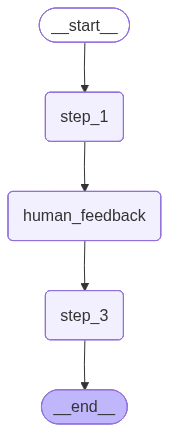

In [43]:
show_graph(graph)

In [44]:
# 輸入
initial_input = {"input": "hello world"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# stream_mode="updates" → 每個 node 跑完只吐出「這個 node 改了什麼」。
#   對照組 "values" → 吐出完整的 state。這裡用 updates 才看得到 __interrupt__ 這個訊號。
#
# 看輸出：跑完 step_1，接著 human_feedback 印出 "---human_feedback---" 後就停住，
# 最後吐出 {'__interrupt__': (Interrupt(value='Please provide feedback:'...))}
# ——這是 graph 在跟外面喊「我卡在這，需要這個答案」。
# 注意 step_3 沒有跑：graph 是真的停住了，不是跳過。此刻 state 已經存進 thread 裡。
for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

---Step 1---
{'step_1': None}


---human_feedback---
{'__interrupt__': (Interrupt(value='Please provide feedback:', id='e8052c889052ec3e144402dca45de05f'),)}




要從 interrupt 處恢復執行，我們可以使用 [`Command` object](https://langchain-ai.github.io/langgraph/how-tos/command/)。

我們會用它從中斷的 state 恢復 graph，並把要從 interrupt 呼叫回傳的值傳給 `resume`。

In [45]:
# Command(resume="go to step 3!") = 把人給的答案送回去。
# ⚠️ 反直覺：第一個參數的位置本來是放「輸入」的，這裡放 Command 代表
#    「這不是新的一輪，是續跑」。靠的是同一個 thread：LangGraph 用 thread_id 撈回存檔，
#    才知道要從哪裡醒過來。
# "go to step 3!" 這串字會變成上面 interrupt() 那行的回傳值，落進 feedback 變數裡。
#
# 對照輸出驗證上面那條踩雷：沒有再印 "---Step 1---"（step_1 已完成，不會重跑），
# 但 "---human_feedback---" 又印了一次——node 從頭重跑的鐵證。
for event in graph.stream(
    Command(resume="go to step 3!"),
    thread,
    stream_mode="updates",
):
    print(event)
    print("\n")

---human_feedback---
{'human_feedback': {'user_feedback': 'go to step 3!'}}


---Step 3---
{'step_3': None}




### Tracing

當我們使用 LangChain 或 LangGraph 時，只要設定好以下環境變數，LangSmith 的記錄功能就會[開箱即用](https://docs.smith.langchain.com/observability/how_to_guides/trace_with_langgraph)：

```
export LANGSMITH_TRACING=true
export LANGSMITH_API_KEY="<your-langsmith-api-key>"
```

以下是上面那段 agent 執行所產生的 LangSmith trace：

https://smith.langchain.com/public/6f77014f-d054-44ed-aa2c-8b06ceab689f/r

我們可以看到，因為使用了 checkpointer，agent 能夠從先前的 state 繼續對話。

### Deployment

我們也可以使用 [LangGraph Platform](https://langchain-ai.github.io/langgraph/concepts/langgraph_platform/) 來部署我們的 graph。

這會建立一個[帶有 API](https://langchain-ai.github.io/langgraph/cloud/reference/api/api_ref.html) 的伺服器，讓我們能用來與 graph 互動，並提供一個互動式 IDE — LangGraph [Studio](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/)。

我們只需要確保專案具有[如下的結構](https://langchain-ai.github.io/langgraph/concepts/application_structure/)：

```
my-app/
├── src/email_assistant # all project code lies within here
│   └── langgraph101.py # code for constructing your graph
├── .env # environment variables
├── langgraph.json  # configuration file for LangGraph
└── pyproject.toml # dependencies for your project
```

`langgraph.json` 這個檔案會指定啟動一個 LangGraph 伺服器所需的相依套件、graphs、環境變數以及其他設定。

為了測試這一點，我們來部署 `langgraph_101.py`。我們已經把它寫在這個 repo 的 `langgraph.json` 檔案中：

```
 "langgraph101": "./src/email_assistant/langgraph_101.py:app",
```

對於 LangGraph Platform，有一系列的[部署選項](https://langchain-ai.github.io/langgraph/tutorials/deployment/)：
 
* 本機部署可以在 repo 的根目錄下執行 `langgraph dev` 來啟動。Checkpoints 會被保存到本機檔案系統。
* 也有各種[自行託管（self-hosted）的選項](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options)。
* 對於託管式（hosted）部署，checkpoints 會透過 postgres [checkpointer](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpointer-libraries) 保存到 Postgres 中。

測試：
```
Draft a response to my boss (boss@company.ai) confirming that I want to attent Interrupt!
```

在這裡我們可以在 Studio 中看到 graph 的視覺化呈現，以及 graph 的 state。

![langgraph_studio](img/langgraph_studio.png)

此外，你也可以在這裡看到本機部署的 API 文件：

http://127.0.0.1:2024/docs

In [ ]:
import sys; print(sys.executable); print(sys.prefix)